# 07 — VAE-LSTM: Variational Autoencoder with LSTM for Battery Health

## Architecture
- **Encoder:** 2-layer Bi-LSTM → μ, log σ² (latent_dim=16)
- **Reparameterization:** z = μ + σ · ε, ε ~ N(0,1)
- **Decoder:** 2-layer LSTM reconstructing input sequences
- **Health Head:** MLP mapping z → SOH prediction
- **Loss:** Reconstruction + β·KL divergence (β annealing) + SOH prediction loss

## Applications
1. SOH prediction from latent health embeddings
2. Anomaly detection via reconstruction error (3σ threshold)
3. Latent space visualization (UMAP)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models.deep.vae_lstm import VAE_LSTM, vae_loss, train_vae, detect_anomalies, BetaScheduler
from src.evaluation.metrics import regression_metrics, tolerance_accuracy
from src.utils.plotting import save_fig
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE, DROPOUT,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')
ensure_version_dirs('v2')

Device: cuda
PyTorch: 2.6.0+cu124


## 1. Load Data

In [2]:
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

# -- v2: intra-battery chronological split --
# For each battery, first 80% of sequences -> train, last 20% -> test
train_idx, test_idx = [], []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    n = len(idxs)
    cut = int(0.8 * n)
    train_idx.extend(idxs[:cut].tolist())
    test_idx.extend(idxs[cut:].tolist())

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, y_train = X_multi[train_idx], y_multi[train_idx]
X_test, y_test = X_multi[test_idx], y_multi[test_idx]
bids_test = bids[test_idx]

from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1444, 32, 12) | Test: (290, 32, 12)


## 2. Build & Train VAE-LSTM

In [3]:
vae = VAE_LSTM(
    input_dim=n_feat, seq_len=seq_len, hidden_dim=128,
    latent_dim=16, n_layers=2, dropout=DROPOUT,
)
print(f"VAE-LSTM params: {sum(p.numel() for p in vae.parameters()):,}")

history = train_vae(
    vae, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=1e-3,
    device=device, patience=EARLY_STOP_PATIENCE,
)
best_epoch = len(history["val_losses"]) - EARLY_STOP_PATIENCE
epochs_trained = len(history["val_losses"])
print(f"Trained {epochs_trained} epochs, best ~ epoch {best_epoch}")
torch.save(vae.state_dict(), str(v2["models_deep"] / "vae_lstm.pt"))

VAE-LSTM params: 820,013


Trained 31 epochs, best ~ epoch 11


## 3. SOH Prediction from Latent Space

In [4]:
vae.eval()
with torch.no_grad():
    out = vae(X_test_t.to(device))
    soh_pred = out["health_pred"].cpu().numpy()
    mu_test = out["mu"].cpu().numpy()

metrics = regression_metrics(y_test, soh_pred)
metrics["tol_2pct"] = tolerance_accuracy(y_test, soh_pred, 2.0)
print("VAE-LSTM SOH Prediction:")
print(f"  MAE  = {metrics['MAE']:.4f}")
print(f"  RMSE = {metrics['RMSE']:.4f}")
print(f"  R²   = {metrics['R2']:.4f}")
print(f"  MAPE = {metrics['MAPE']:.2f}%")
print(f"  Tol.Acc (±2%) = {metrics['tol_2pct']:.2%}")

VAE-LSTM SOH Prediction:
  MAE  = 8.4949
  RMSE = 10.0393
  R²   = 0.7267
  MAPE = 14.25%
  Tol.Acc (±2%) = 9.31%


## 4. Anomaly Detection
Reconstruction error exceeding mean + 3σ flags anomalous cycles.

Threshold (mean + 3σ): 2.992219
Anomalies detected: 0 / 290 (0.00%)
Mean recon error (train): 0.840392 ± 0.717275
Mean recon error (test):  1.207144 ± 0.559126


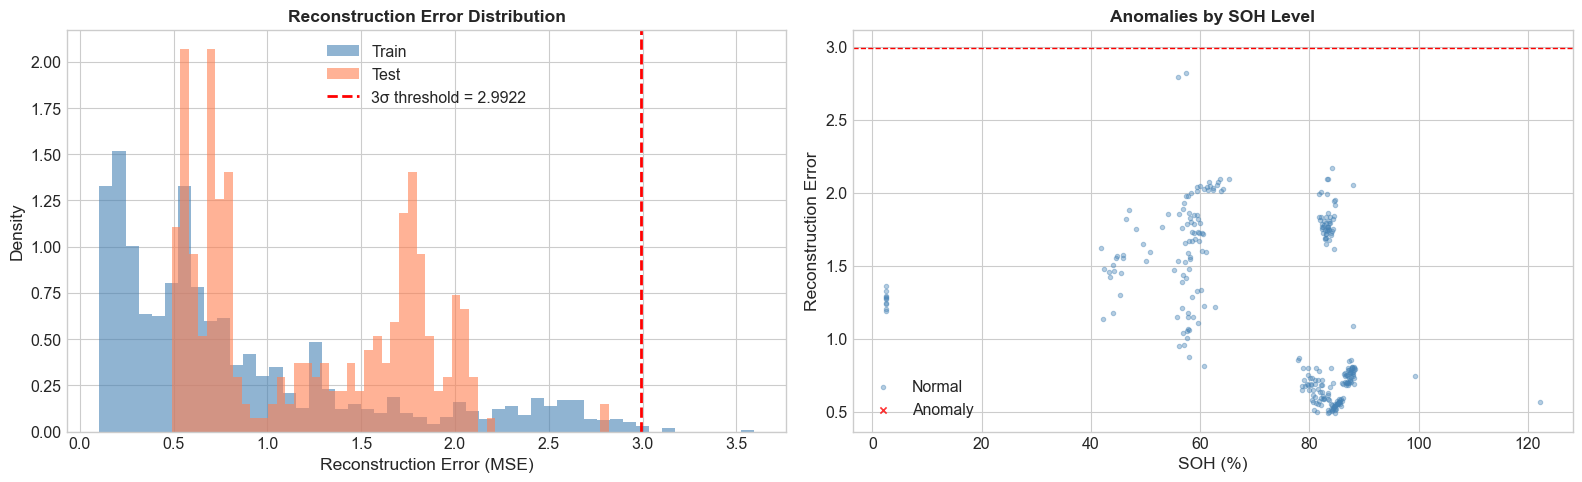

In [5]:
# Get reconstruction errors for training set (to fit threshold)
vae.eval()
with torch.no_grad():
    out_train = vae(X_train_t.to(device))
    recon_train = torch.mean((X_train_t.to(device) - out_train["recon"]) ** 2, dim=(1, 2)).cpu().numpy()
    
    out_test = vae(X_test_t.to(device))
    recon_test = torch.mean((X_test_t.to(device) - out_test["recon"]) ** 2, dim=(1, 2)).cpu().numpy()

threshold = recon_train.mean() + 3 * recon_train.std()
anomalies = recon_test > threshold

print(f"Threshold (mean + 3σ): {threshold:.6f}")
print(f"Anomalies detected: {anomalies.sum()} / {len(anomalies)} ({anomalies.mean():.2%})")
print(f"Mean recon error (train): {recon_train.mean():.6f} ± {recon_train.std():.6f}")
print(f"Mean recon error (test):  {recon_test.mean():.6f} ± {recon_test.std():.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].hist(recon_train, bins=50, alpha=0.6, label="Train", density=True, color="steelblue")
axes[0].hist(recon_test, bins=50, alpha=0.6, label="Test", density=True, color="coral")
axes[0].axvline(x=threshold, color="red", linestyle="--", linewidth=2, label=f"3σ threshold = {threshold:.4f}")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Density")
axes[0].set_title("Reconstruction Error Distribution", fontweight="bold")
axes[0].legend()

# Anomalies vs SOH
axes[1].scatter(y_test[~anomalies], recon_test[~anomalies], s=10, alpha=0.4, label="Normal", color="steelblue")
axes[1].scatter(y_test[anomalies], recon_test[anomalies], s=20, alpha=0.8, label="Anomaly", color="red", marker="x")
axes[1].axhline(y=threshold, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("SOH (%)")
axes[1].set_ylabel("Reconstruction Error")
axes[1].set_title("Anomalies by SOH Level", fontweight="bold")
axes[1].legend()

plt.tight_layout()
save_fig(fig, "v2_vae_anomaly_detection")
plt.show()

## 5. Latent Space Visualization (UMAP)

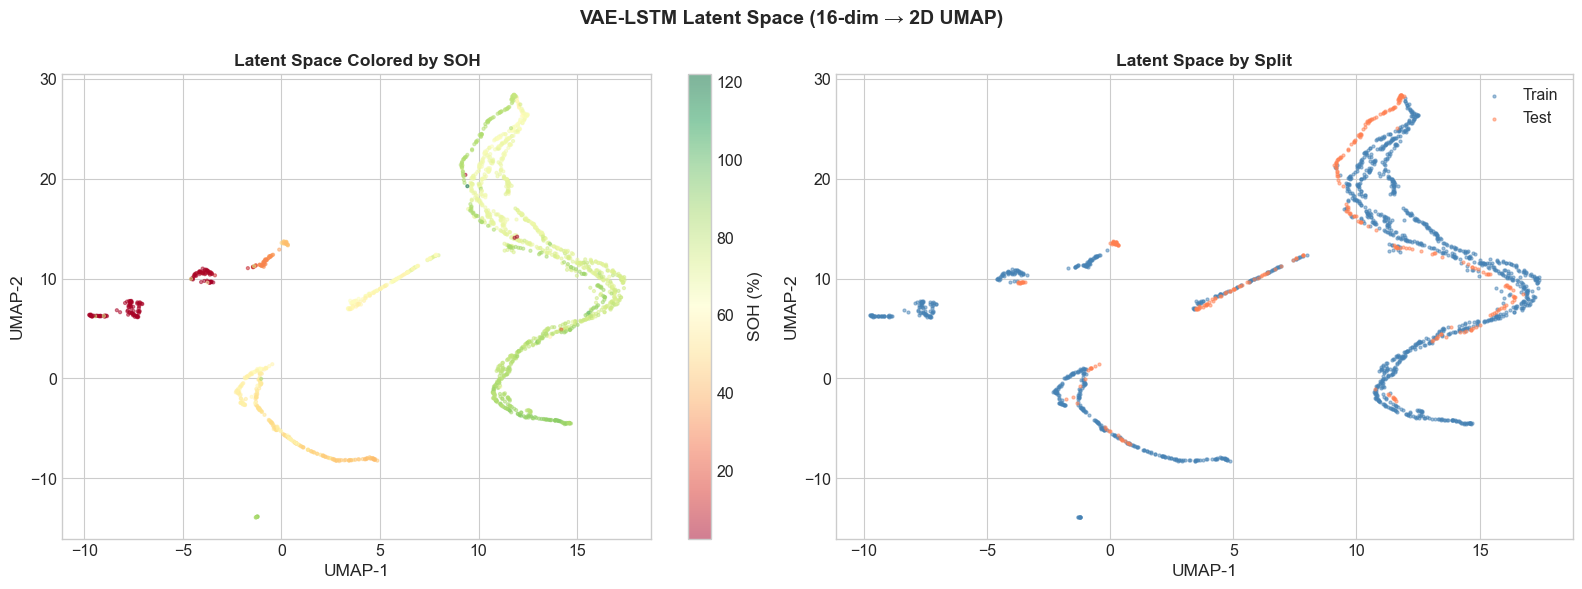

In [6]:
import umap

# Get all latent vectors
vae.eval()
with torch.no_grad():
    out_all = vae(torch.FloatTensor(
        np.vstack([X_train, X_test])
    ).to(device))
    mu_all = out_all["mu"].cpu().numpy()

y_all = np.concatenate([y_train, y_test])
split_labels = np.array(["Train"] * len(y_train) + ["Test"] * len(y_test))

# UMAP 2D
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
z_2d = reducer.fit_transform(mu_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by SOH
sc = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=y_all, cmap="RdYlGn", s=5, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="SOH (%)")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].set_title("Latent Space Colored by SOH", fontweight="bold")

# Color by split
colors = {"Train": "steelblue", "Test": "coral"}
for label in ["Train", "Test"]:
    mask = split_labels == label
    axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], s=5, alpha=0.5,
                    label=label, color=colors[label])
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
axes[1].set_title("Latent Space by Split", fontweight="bold")
axes[1].legend()

plt.suptitle("VAE-LSTM Latent Space (16-dim → 2D UMAP)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v2_vae_latent_umap")
plt.show()

## 6. Training Curves & Actual vs Predicted

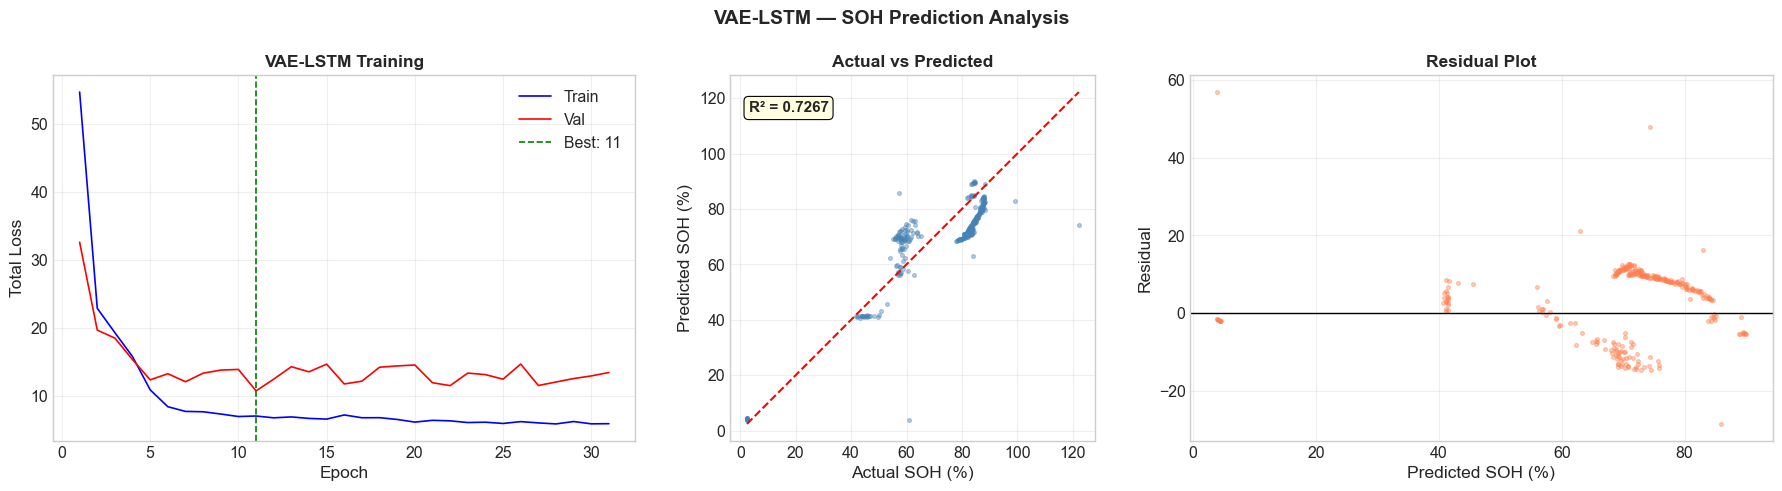

Results saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
epochs_range = range(1, len(history["train_losses"]) + 1)
axes[0].plot(epochs_range, history["train_losses"], "b-", label="Train")
axes[0].plot(epochs_range, history["val_losses"], "r-", label="Val")
axes[0].axvline(x=best_epoch, color="green", linestyle="--", label=f"Best: {best_epoch}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Total Loss")
axes[0].set_title("VAE-LSTM Training", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, soh_pred, s=8, alpha=0.4, c="steelblue")
lims = [min(y_test.min(), soh_pred.min()), max(y_test.max(), soh_pred.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5)
axes[1].annotate(f"R² = {metrics['R2']:.4f}", xy=(0.05, 0.9), xycoords="axes fraction",
                 fontsize=11, fontweight="bold", bbox=dict(boxstyle="round", facecolor="lightyellow"))
axes[1].set_xlabel("Actual SOH (%)"); axes[1].set_ylabel("Predicted SOH (%)")
axes[1].set_title("Actual vs Predicted", fontweight="bold")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

# Residuals
residuals = y_test - soh_pred
axes[2].scatter(soh_pred, residuals, s=8, alpha=0.4, c="coral")
axes[2].axhline(y=0, color="black", linewidth=1)
axes[2].set_xlabel("Predicted SOH (%)"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residual Plot", fontweight="bold"); axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE-LSTM — SOH Prediction Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v2_vae_lstm_prediction")
plt.show()

# Save results
import json
with open(v2["results"] / "v2_vae_lstm_results.json", "w") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
print("Results saved.")